In [ ]:
from copy import deepcopy
from numba import njit
import numpy as np 
import matplotlib.pyplot as plt
import neuralnet as nn 
from neuralnet.preprocess import prepare_data
from neuralnet.activations import step, derivative_htanh 
from neuralnet.losses import l2_hinge_loss_gradient
from scipy.optimize import curve_fit
from joblib import Parallel, delayed

layer_sizes = [784,512,512,512,10]
βs = np.arange(0,1.4,.1)

def power_law(t,γ):
    return t**γ

def linear(x, beta, const):
    return beta * x + const

def map_nn_to_spin_glass(x: np.ndarray[:], spin_net: nn.NeuralNetwork) -> list[np.ndarray]:
    """
    Map a neural network to an Ising-model spin-glass with external magnetic field.

    Args:
        x (array): Input data point.
        spin_net (object): Neural network with weights and biases.

    Returns:
        list: Spin configurations at each layer of the network.
    """
    # Initialize spin configurations
    spins = [np.where(step(x) > .5, 1, -1)]  # Input layer spins
    
    # Iterate over the layers of the network
    activation = spins[0]
    for l in range(spin_net.layer_n - 1):
        # Compute activation and determine spins for the current layer
        activation = step(spin_net.weights[l] @ activation + spin_net.bias[l])
        spins.append(np.where(activation > 0, 1, -1))
    
    return spins
  


def calculate_hamiltonian(J: list[np.ndarray[:,:]], S: list[np.ndarray[:]],β: (int| float)) -> (int | float):

    """
    Calculates the hamiltonian for a multi-layer spin-glass model

    Parameters:
    ----------
    J : list
        A list of learning rates (η) to test. Default is [1e-4, 1e-2, 1e-1].
    S : list
        A list of momentum values (γ) to test, including None for no momentum.
        Default is [None, 1e-2, 1e-1].
    Returns:
    -------
    list[tuple]
        A list of tuples representing the results for each hyperparameter combination.
        Each tuple contains:
            - Activation function name (str).
            - Learning rate (η).
            - Momentum value (γ).
            - Pool size.
            - A list of validation accuracy percentages over the runs.

    Example:
    --------
    result = search_hyperparameters(
        learning_rates=[0.001, 0.01],
        momentums=[0.9, None],
        pools=[32],
        runs=50,
        epoch_unit=5
    )
    """
    β
    n = len(J)
    H = 0.0
    for l in range(0, n):
        si , sj = S[l],  S[l+1]
        W = J[l]
        H -= np.sum((W @ si) * sj)

    return H 

@njit
def jitted_calculate_hamiltonian(J: list[np.ndarray[:,:]], S: list[np.ndarray[:]],β: (int| float)) -> (int | float):

    """
    Calculates the hamiltonian for a multi-layer spin-glass model

    Parameters:
    ----------
    J : list
        A list of learning rates (η) to test. Default is [1e-4, 1e-2, 1e-1].
    S : list
        A list of momentum values (γ) to test, including None for no momentum.
        Default is [None, 1e-2, 1e-1].
    Returns:
    -------
    list[tuple]
        A list of tuples representing the results for each hyperparameter combination.
        Each tuple contains:
            - Activation function name (str).
            - Learning rate (η).
            - Momentum value (γ).
            - Pool size.
            - A list of validation accuracy percentages over the runs.

    Example:
    --------
    result = search_hyperparameters(
        learning_rates=[0.001, 0.01],
        momentums=[0.9, None],
        pools=[32],
        runs=50,
        epoch_unit=5
    )
    """
    β
    n = len(J)
    H = 0.0
    for l in range(0, n):
        si , sj = S[l],  S[l+1]
        W = J[l]
        H -= np.sum((W @ si) * sj)

    return H 

def calculate_heat_capacity(J,S,β):

     # Total number of spins
    N = sum(len(s) for s in S)
    
    # Compute energy 
    Si = calculate_hamiltonian(J,S)
    
    # Compute pairwise spin product sum (SiSj)
    SiSj = 0.0
    for i in range(len(S) - 1):
        # Broadcast multiply only valid ranges between S[i] and S[i+1]
        SiSj += np.sum(S[i][:, None] * S[i + 1])
    
    # Calculate susceptibility
    χ = β * (SiSj / N - (Si / N)**2)
    
    return  χ

def calculate_magnetization(J, S: list[np.ndarray[:]],β) -> (float | int):
    """
    Calculates the magnetization sum(s)/N for a multi-layer spin-glass model

    """
    β
    N = sum(len(s) for s in S)
    M = sum(np.sum(s) for s in S)/N
    return M

def calculate_overlap(J,S,β):
    β
    N = sum(len(s) for s in S)
    M = sum(np.sum(s**2) for s in S)/N
    return M

def calculate_second_magnetization(J, S: list[np.ndarray[:]],β) -> (float | int):
    """
    Calculates the magnetization sum(s)/N for a multi-layer spin-glass model

    """
    N = sum(len(s) for s in S)
    M2 = sum([np.sum(s**2) for s in S])
    return M2/N

def calculate_fourth_magnetization(J, S: list[np.ndarray[:]],β) -> (float | int):
    """
    Calculates the magnetization sum(s)/N for a multi-layer spin-glass model

    """
    N = sum(len(s) for s in S)
    M = (sum(np.sum(s) for s in S)/N)**4
    return M

# def calculate_susceptibility(J, S: list[np.ndarray[:]], β: (int | float)) -> (int | float):
#     """

    
    
#     """
#     # Total number of spins
#     N = sum(len(s) for s in S)
    
#     # Compute total spin sum (Si)
#     Si = sum(np.sum(s) for s in S)
    
#     # Compute pairwise spin product sum (SiSj)
#     SiSj = 0.0
#     for i in range(len(S) - 1):
#         # Broadcast multiply only valid ranges between S[i] and S[i+1]
#         SiSj += np.sum(S[i][:, None] * S[i + 1])
    
#     # Calculate susceptibility
#     χ = β/N * (SiSj - (Si)**2)
    
#     return  χ


def calculate_susceptibility_configs(S_history: list[list[np.ndarray]], β: float) -> float:
    """
    Calculate the magnetic susceptibility for a layered spin system.

    Parameters
    ----------
    S_history : list[list[np.ndarray]]
        A list of spin configurations (after burn-in), where each configuration is
        a list of 1D arrays representing layered spins.
    β : float
        Inverse temperature (1 / T).

    Returns
    -------
    float
        Magnetic susceptibility χ.
    """
    # Total number of configurations (samples)
    n_samples = len(S_history)

    if n_samples == 0:
        raise ValueError("No spin configurations provided in S_history.")

    # Compute the total number of spins across all layers
    N = sum(len(layer) for layer in S_history[0])  # Total number of spins per configuration

    # Magnetizations for all configurations
    magnetizations = []

    for S_config in S_history:
        # Calculate the total magnetization for this configuration
        total_magnetization = sum(np.sum(layer) for layer in S_config)
        magnetizations.append(total_magnetization / N)  # Normalize by the total number of spins

    # Compute <M> and <M^2>
    avg_M = np.mean(magnetizations)  # <M>
    avg_M2 = np.mean(np.array(magnetizations)**2)  # <M^2>

    # Susceptibility formula
    chi = β * N * (avg_M2 - avg_M**2)

    return chi
    


def calculate_specific_heat_on_configs(J: list[np.ndarray[:,:]], S_history: list[np.ndarray], β: float) -> float:
    """
    Calculate the specific heat for a layered spin system.

    Parameters
    ----------
    E_history : list[float]
        A list of total energy values for different Monte Carlo configurations.
    β : float
        Inverse temperature (1 / T).
    N : int
        Total number of spins in the system.

    Returns
    -------
    float
        Specific heat C_v.
    """
    # Total number of configurations (samples)
    n_samples = len(S_history)
    N = np.sum([len(s) for s in S_history])

    if n_samples == 0:
        raise ValueError("No energy configurations provided in E_history.")

    energy_configs = []
    for s_config in S_history:

        energy_configs.append(calculate_hamiltonian(J,s_config,β))
    # Compute <E> and <E^2>
    avg_E = np.mean(energy_configs)  # <E>
    avg_E2 = np.mean(np.array(energy_configs)**2)  # <E^2>

    # Compute specific heat using fluctuation formula
    C_v = (β**2 / N) * (avg_E2 - avg_E**2)

    return C_v

def compute_before_after_hamiltonians(x,spin_net,spin_net_after):
    spin_glass_vector = map_nn_to_spin_glass(x, spin_net)
    spin_glass_vector_after = map_nn_to_spin_glass(x, spin_net_after)
    H = calculate_hamiltonian(spin_net.weights, spin_glass_vector)
    H_after = calculate_hamiltonian(spin_net_after.weights, spin_glass_vector_after)
    return H, H_after
    
def monte_carlo_on_spins(J: list[np.ndarray[:,:]], 
                         S: list[np.ndarray[:]],
                         thermodynamic_quantities: list[callable],  
                         β: (int | float),iterations: (int),
                         burnin: (int), 
                         inplace=False) -> (list[np.ndarray[:],list[float]]):

    """
    Perform Ising Monte-Carlo on spins

    Parameters
    ----------
    J : list[np.ndarray[:,:]]
        list of 2d arrays representing bond matrices between layers of spins
    S : list[np.ndarray[:]]
        list of 1d arrays each one representing layer of spin
    thermodynamic_quantities: list[callable]
        pass a list of thermo functions with signature f(J,S,β)
    β : float 
        inverse temperature
    iterations : int, optional
        number of iterations for simulation

    Returns
    -------
    New final configuration S_ of spins and a list of thermodynamic quantities for all configurations
    """
    
    thermodynamic_info = []
    if inplace is True:
        S_ = S
    else:
        S_ = deepcopy(S)

    for _ in range(0,iterations):
        array_index = np.random.randint(0, len(S_) - 1)
        element_index = np.random.randint(0, len(S[array_index]) - 1)
        E0 = calculate_hamiltonian(J,S_,β)
        S_[array_index][element_index] = -1.0 * S_[array_index][element_index]
        E = calculate_hamiltonian(J,S_,β)
        ΔE = E-E0 
        if ΔE < 0 : 
            S_[array_index][element_index]= 1.0 * S_[array_index][element_index]

        else: 
            if np.random.rand() > np.exp(-β*ΔE) :
                # Reject the spin flip: restore the original spin
                S_[array_index][element_index] = -1.0 * S_[array_index][element_index]

                
        if thermodynamic_quantities is None:
            pass
        else:
            thermodynamics = [f(J,S_,β) for f in thermodynamic_quantities]
            thermodynamic_info.append(thermodynamics)
            
    return S_ , thermodynamic_info[burnin:]

def monte_carlo_on_spins_w_history(J: list[np.ndarray[:,:]], 
                         S: list[np.ndarray[:]],
                         thermodynamic_quantities: list[callable],  
                         β: (int | float),iterations: (int),
                         burnin: (int), 
                         inplace=False) -> (list[list[np.ndarray[:]],list[float]]):

    """
    Perform Ising Monte-Carlo on spins

    Parameters
    ----------
    J : list[np.ndarray[:,:]]
        list of 2d arrays representing bond matrices between layers of spins
    S : list[np.ndarray[:]]
        list of 1d arrays each one representing layer of spin
    thermodynamic_quantities: list[callable]
        pass a list of thermo functions with signature f(J,S,β)
    β : float 
        inverse temperature
    iterations : int, optional
        number of iterations for simulation

    Returns
    -------
    New final configuration S_ of spins and a list of thermodynamic quantities for all configurations
    """
    
    thermodynamic_info = []
    if inplace is True:
        S_ = S
    else:
        S_ = deepcopy(S)

    history = [deepcopy(S_)]
    for _ in range(0,iterations):
        array_index = np.random.randint(0, len(S_) - 1)
        element_index = np.random.randint(0, len(S[array_index]) - 1)
        E0 = calculate_hamiltonian(J,S_,β)
        S_[array_index][element_index] = -1.0 * S_[array_index][element_index]
        E = calculate_hamiltonian(J,S_,β)
        ΔE = E-E0 
        if ΔE < 0 : 
            pass
        else: 
            if np.random.rand() > np.exp(-β*ΔE) :
                # Reject the spin flip: restore the original spin
                S_[array_index][element_index] = -1.0 * S_[array_index][element_index]

        history.append(deepcopy(S_))
                
        if thermodynamic_quantities :
            thermodynamics = [f(J,S_,β) for f in thermodynamic_quantities]
            thermodynamic_info.append(thermodynamics)
            
    return history[burnin:] , thermodynamic_info[burnin:]



@njit
def monte_carlo_step(J: np.ndarray, S: np.ndarray, β: float, random_numbers: np.ndarray, array_indices: np.ndarray, element_indices: np.ndarray) -> np.ndarray:
    """
    Perform a single Monte Carlo step.
    """
    for i in range(len(random_numbers)):
        # Randomly select a spin to flip
        array_idx = array_indices[i]
        element_idx = element_indices[array_idx, i]

        # Calculate energy before flip
        E0 = calculate_hamiltonian(J, S, β)

        # Flip the spin
        S[array_idx, element_idx] *= -1

        # Calculate energy after flip
        E1 = calculate_hamiltonian(J, S, β)

        # Calculate energy change
        ΔE = E1 - E0

        # Metropolis acceptance criterion
        if ΔE > 0 and random_numbers[i] >= np.exp(-β * ΔE):
            # Reject the flip: restore the original spin
            S[array_idx, element_idx] *= -1

    return S


def jitted_monte_carlo_on_spins_w_history(J: list[np.ndarray], 
                                   S: list[np.ndarray],
                                   thermodynamic_quantities: list[callable],  
                                   β: float, 
                                   iterations: int,
                                   burnin: int, 
                                   inplace: bool = False) -> tuple[list[list[np.ndarray]], list[list[float]]]:
    """
    Perform Ising Monte-Carlo on spins with history, optimized with Numba.

    Parameters
    ----------
    J : list[np.ndarray]
        List of 2D arrays representing bond matrices between layers of spins.
    S : list[np.ndarray]
        List of 1D arrays, each representing a layer of spins.
    thermodynamic_quantities : list[callable]
        List of thermodynamic functions with signature f(J, S, β).
    β : float
        Inverse temperature.
    iterations : int
        Number of iterations for simulation.
    burnin : int
        Number of initial iterations to discard (burn-in period).
    inplace : bool, optional
        If True, modify the input spin configuration in place. Default is False.

    Returns
    -------
    tuple[list[list[np.ndarray]], list[list[float]]]
        A tuple containing:
        - The history of spin configurations after the burn-in period.
        - The thermodynamic quantities computed for each configuration after the burn-in period.
    """
    # Convert lists to 3D NumPy arrays for Numba compatibility
    J_array = np.stack(J)  # Shape: (num_layers, num_spins, num_spins)
    S_array = np.stack(S)  # Shape: (num_layers, num_spins)

    # Precompute random indices and numbers for the entire simulation
    array_indices = np.random.randint(0, S_array.shape[0], size=iterations)
    element_indices = np.random.randint(0, S_array.shape[1], size=(S_array.shape[0], iterations))
    random_numbers = np.random.rand(iterations)

    # Initialize history and thermodynamic info with preallocated memory
    history = []
    thermodynamic_info = []

    # Use inplace modification or deep copy
    if inplace:
        S_ = S_array
    else:
        S_ = S_array.copy()

    # Perform Monte Carlo steps
    S_ = monte_carlo_step(J_array, S_, β, random_numbers, array_indices, element_indices)

    # Store history and thermodynamic quantities after burn-in
    for i in range(iterations):
        if i >= burnin:
            history.append([np.copy(layer) for layer in S_])
            if thermodynamic_quantities:
                thermodynamics = [f(J, S_, β) for f in thermodynamic_quantities]
                thermodynamic_info.append(thermodynamics)

    return history, thermodynamic_info

def run_simulation(T, J, S,burnin, n_configs):
    """
    Run Monte Carlo simulation for a given temperature T and return computed thermodynamic properties.

    Parameters:
    ----------
    T : float
        Temperature for the simulation.
    J : list[np.ndarray]
        Bond matrices representing the interaction strengths.
    S : list[np.ndarray]
        Initial spin configurations (layered structure).
    n_configs : int
        Number of Monte Carlo configurations.

    Returns:
    -------
    tuple: (T, average_energy, average_magnetization, average_susceptibility, average_heat_capacity)
    """
    β = 1 / T

    # Run Monte Carlo simulation
    S_history, _ = monte_carlo_on_spins_w_history(
        J,
        S,
        thermodynamic_quantities=None, 
        β=β,
        burnin=burnin, 
        iterations=n_configs
    )

    # Compute thermodynamic properties
    average_energy = np.sum([calculate_hamiltonian(J, s_config, β) for s_config in S_history]) / n_configs
    average_magnetization = np.sum([calculate_magnetization(J, s_config, β) for s_config in S_history]) / n_configs
    average_susceptibility = calculate_susceptibility_configs(S_history, β)
    average_heat_capacity = calculate_specific_heat_on_configs(J, S_history, β)

    return (T, average_energy, average_magnetization, average_susceptibility, average_heat_capacity)


def jitted_run_simulation(T, J, S,burnin, n_configs):
    """
    Run Monte Carlo simulation for a given temperature T and return computed thermodynamic properties.

    Parameters:
    ----------
    T : float
        Temperature for the simulation.
    J : list[np.ndarray]
        Bond matrices representing the interaction strengths.
    S : list[np.ndarray]
        Initial spin configurations (layered structure).
    n_configs : int
        Number of Monte Carlo configurations.

    Returns:
    -------
    tuple: (T, average_energy, average_magnetization, average_susceptibility, average_heat_capacity)
    """
    β = 1 /T

    # Run Monte Carlo simulation
    S_history, _ = jitted_monte_carlo_on_spins_w_history(
        J,
        S,
        thermodynamic_quantities=None, 
        β=β,
        burnin=burnin, 
        iterations=n_configs
    )

    # Compute thermodynamic properties
    average_energy = np.sum([calculate_hamiltonian(J, s_config, β) for s_config in S_history]) / n_configs
    average_magnetization = np.sum([calculate_magnetization(J, s_config, β) for s_config in S_history]) / n_configs
    average_susceptibility = calculate_susceptibility_configs(S_history, β)
    average_heat_capacity = calculate_specific_heat_on_configs(J, S_history, β)

    return (T, average_energy, average_magnetization, average_susceptibility, average_heat_capacity)


def replica_exchange_monte_carlo(S: list[np.ndarray[:]] ,
                                 replicas: list[nn.NeuralNetworkwMemory] ,
                                 βs: list[float],
                                 n_exchanges: (int | float),
                                 thermodynamics = list[tuple[callable,tuple]],
                                 iteration_per_exchange: (int | float)=100, 
                                 burnin: int = 100,
                                 inplace: bool=False):
    """
    Perform Replica Exchange Monte Carlo (REMC) on a set of replicas, simulating spin configurations
    at different inverse temperatures (βs) and swapping configurations between adjacent replicas.

    Parameters:
    -----------
    S : list[np.ndarray[:]]
        A list of arrays representing the spin configurations for each replica.
    
    replicas : list[NeuralNetworkwMemory]
        A list of objects, where each object represents a replica (e.g., a neural network with weights).

    βs : list[float]
        A list of inverse temperatures (β values) corresponding to each replica.
    
    n : int | float, optional, default=10
        The number of exchange cycles to perform. Each cycle includes spin updates 
        and attempted exchanges between adjacent replicas.

    iteration_per_exchange : int | float, optional, default=100
        The number of Monte Carlo iterations to run on each replica between exchange attempts.

    inplace : bool, optional, default=False
        If True, modifies the input `S` and `replicas` directly. If False, deep copies are used,
        and the original inputs remain unchanged.

    Returns:
    --------
    replicas_ : list[NeuralNetworkwMemory]
        The list of updated replicas after the REMC process.

    S_ : list[np.ndarray[:]]
        The list of updated spin configurations for each replica.

    Notes:
    ------
    - The algorithm alternates between simulating the replicas independently (using `monte_carlo_on_spins`) 
      and attempting exchanges between adjacent replicas.
    - Exchanges are performed based on the Metropolis-like probability that ensures detailed balance:
        P_exchange = min(1, exp((β_i - β_{i+1}) * (E_{i+1} - E_i)))
      where E_i is the Hamiltonian energy of replica `i`.
    - If `inplace=True`, the input `S` and `replicas` are directly modified.

    Example Usage:
    --------------
    >>> replicas = [NeuralNetworkwMemory(weights=np.random.rand(5, 5)) for _ in range(4)]
    >>> S = [np.random.choice([-1, 1], size=(5,)) for _ in range(4)]
    >>> βs = [1.0, 0.8, 0.6, 0.4]
    >>> replicas_, S_ = replica_exchange_monte_carlo(S, replicas, βs, n=20, iteration_per_exchange=200)
    """

    if inplace is True:
        replicas_,  S_ , βs_ = replicas, S, βs
    else:
        replicas_,  S_ , βs_= (deepcopy(replicas),
                               deepcopy(S), deepcopy(βs))


    n_replicas = len(replicas)

    for _ in range(0,n_exchanges):
        #simulate replicas 
        # parallelize 
        S_tmp = []
        thermo_macrostates =[]
        # perform mcmc ising spin 
        for (r,s,β) in zip(replicas_,S_, βs_): 
            J = r.weights
            s_ , t = monte_carlo_on_spins(J=J,
                                          S=s,
                                          thermodynamic_quantities=thermodynamics,
                                          β=β,
                                          iterations=iteration_per_exchange)
            
            S_tmp.append(s_); thermo_macrostates.append(t[burnout:])

        # exchange the replicas 
        for i in range(0,n_replicas-1):
            E0, E1 = (calculate_hamiltonian(replicas_[i].weights,S_[i]), 
                      calculate_hamiltonian(replicas_[i+1].weights,S_[i+1]))
            P_exchange = np.min([1,np.exp((βs[i]-βs[i+1])*(E1-E0))])
            r = np.random.rand(1)
            if P_exchange > r:
                replicas_[i], replicas_[i+1] = replicas_[i+1], replicas_[i]
                S_tmp[i], S_tmp[i+1] = S_tmp[i+1], S_tmp[i]
                thermo_macrostates[i], thermo_macrostates[i+1] = thermo_macrostates[i+1], thermo_macrostates[i]
            else : 
                pass 

        S_ = S_tmp

    return [ (replicas_[i], S_[i],thermo_macrostates[i]) for i in range(0,len(S_))]

In [4]:
x_train, y_train, x_test, y_test = prepare_data()

In [ ]:
# for 2 d ...
hidden_2d_layers = [2 for _ in range(0,128)]
layer_size_2d = [4] + hidden_2d_layers + [4]
J = 1
n = 20
x = np.array([-1,1,1,1])
δt = 2/(n**2)
z = 4
βc = 2.269
βs = [ βc*(1-i*δt) for i in range(0,n)]

layered_ising_model = nn.NeuralNetwork(
        layer_size_2d,
        activation_function=step,
        activation_derivative=derivative_htanh,
        cost_function=None,
        cost_grad=l2_hinge_loss_gradient,
    )

N = sum(layer_size_2d)

    # kaiming-like initialization 
layered_ising_model.weights = [np.full((layered_ising_model.layer_sizes[i], layered_ising_model.layer_sizes[i - 1]), J) for i in range(1,layered_ising_model.hidden_layer_n + 2)]

layered_ising_model.bias = [
                    np.zeros(layered_ising_model.layer_sizes[i])
                    for i in range(1, layered_ising_model.hidden_layer_n + 2)]

δt = 2/(n)
βs = [ βc*(1-i*δt) for i in range(0,n)]
replicas = [deepcopy(layered_ising_model) for _ in range(0,n)]
# S = [map_nn_to_spin_glass(x, r) for r in replicas]
# S = map_nn_to_spin_glass(x,layered_ising_model)

S = [np.random.choice([-1.0,1.0], size=s) for s in layer_size_2d]



In [235]:
# find β, critical exponent of M, and γ , critical exponent of susceptibility
# check that system is decreasing 
χs= []
Ts = np.arange(1,4,1/n)    
n_configs = 3048
N = np.sum(len(s) for s in S)
print(N)
for T in Ts:
    print(f"Calculating at {T}...")
    layered_ising_model_info = monte_carlo_on_spins(
                                            layered_ising_model.weights,
                                            S,
                                            thermodynamic_quantities=None, 
                                            β=1/T,
                                            burnin=0, 
                                            iterations=n_configs)
                
    χ = 1/(T*N**2)*(2/(n_configs*N**2) * np.sum( np.sum(s**2) for s in S) - (2/n_configs)**2*(np.sum( np.sum(s) for s in S))**2)
    print(f"χ: {χ}")
    χs.append(χ)

/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_46900/3744858752.py:6: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  N = np.sum(len(s) for s in S)


264
Calculating at 1.0...


/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_46900/3744858752.py:18: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  χ = 1/(T*N**2)*(2/(n_configs*N**2) * np.sum( np.sum(s**2) for s in S) - (2/n_configs)**2*(np.sum( np.sum(s) for s in S))**2)


χ: -8.539175739109656e-10
Calculating at 1.05...
χ: -8.132548322961576e-10
Calculating at 1.1...
χ: -7.762887035554232e-10
Calculating at 1.1500000000000001...
χ: -7.425370207921439e-10
Calculating at 1.2000000000000002...
χ: -7.115979782591379e-10
Calculating at 1.2500000000000002...


KeyboardInterrupt: 

In [402]:
# Perform test to check that MCMC works 
hidden_2d_layers = [2 for _ in range(0,4)]
layer_size_2d = [4] + hidden_2d_layers + [4]
J = 1
x = np.random.choice([-1.0,1.0],(4))
n_configs = int(10e5)
burnin =int(.2*n_configs)

layered_ising_model = nn.NeuralNetwork(
        layer_size_2d,
        activation_function=step,
        activation_derivative=derivative_htanh,
        cost_function=None,
        cost_grad=l2_hinge_loss_gradient,
    )

# Ising spin 
layered_ising_model.weights = [np.full((layered_ising_model.layer_sizes[i], layered_ising_model.layer_sizes[i - 1]), J) for i in range(1,layered_ising_model.hidden_layer_n + 2)]

layered_ising_model.bias = [
                    np.zeros(layered_ising_model.layer_sizes[i])
                    for i in range(1, layered_ising_model.hidden_layer_n + 2)]

S = [np.random.choice([-1.0,1.0], size=s) for s in layer_size_2d]

W = layered_ising_model.weights
Ts = np.arange(0.1, 5.0, 0.01)
# Parallel execution using Joblib
results = Parallel(n_jobs=-1)(delayed(run_simulation)(T, W, S,burnin, n_configs) for T in Ts)

# Sort results and unpack
results.sort(key=lambda x: x[0])  
E, M, χs, Cs = zip(*[(e, m, χ, c) for _, e, m, χ, c in results])

In [ ]:
# Perform test to check that MCMC works 
hidden_2d_layers = [2 for _ in range(0,14)]
layer_size_2d = [4] + hidden_2d_layers + [4]
J = 1
x = np.random.choice([-1.0,1.0],(4))
n_configs = int(10e5)
burnin =int(.2*n_configs)

layered_ising_model = nn.NeuralNetwork(
        layer_size_2d,
        activation_function=step,
        activation_derivative=derivative_htanh,
        cost_function=None,
        cost_grad=l2_hinge_loss_gradient,
    )

# Ising spin 
layered_ising_model.weights = [np.full((layered_ising_model.layer_sizes[i], layered_ising_model.layer_sizes[i - 1]), J) for i in range(1,layered_ising_model.hidden_layer_n + 2)]

layered_ising_model.bias = [
                    np.zeros(layered_ising_model.layer_sizes[i])
                    for i in range(1, layered_ising_model.hidden_layer_n + 2)]

S = [np.random.choice([-1.0,1.0], size=s) for s in layer_size_2d]

W = layered_ising_model.weights
Ts = np.arange(0.1, 5.0, 0.01)
# Parallel execution using Joblib
results = Parallel(n_jobs=-1)(delayed(run_simulation)(T, W, S,burnin, n_configs) for T in Ts)
# Sort results and unpack
results.sort(key=lambda x: x[0])  
E, M, χs, Cs = zip(*[(e, m, χ, c) for _, e, m, χ, c in results])

ValueError: all input arrays must have the same shape

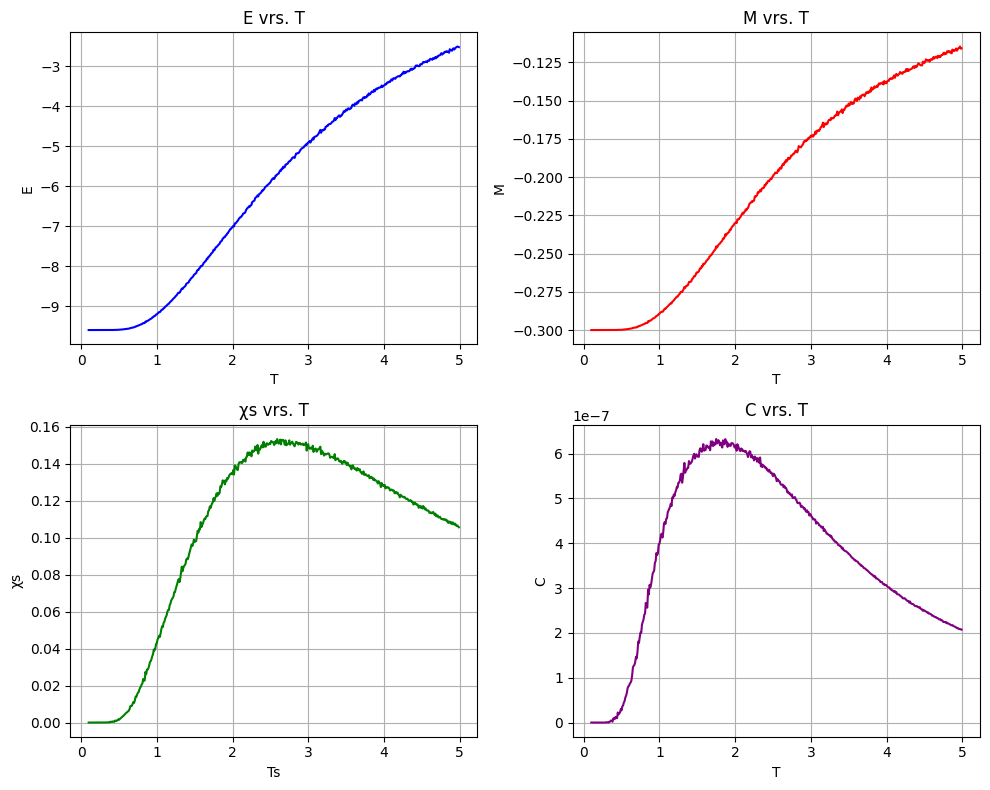

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns

# Plot data in each subplot
axs[0, 0].plot(Ts, E, color='blue')
axs[0, 0].set_title('E vrs. T')
axs[0, 0].set_xlabel('T')
axs[0, 0].set_ylabel('E')
axs[0,0].grid()

axs[0, 1].plot(Ts, M, color='red')
axs[0, 1].set_title('M vrs. T')
axs[0, 1].set_xlabel('T')
axs[0, 1].set_ylabel('M')
axs[0,1].grid()


axs[1, 0].plot(Ts, χs, color='green')
axs[1, 0].set_title('χs vrs. T')
axs[1, 0].set_xlabel('Ts')
axs[1, 0].set_ylabel('χs')
axs[1,0].grid()

axs[1, 1].plot(Ts, Cs, color='purple')
axs[1, 1].set_title('C vrs. T')
axs[1, 1].set_xlabel('T')
axs[1, 1].set_ylabel('C')
axs[1,1].grid()

# Adjust layout to prevent overlap
plt.tight_layout()
# Show the plot
plt.show()



In [ ]:
Tc_index = np.argmax(χs)
Tc = Ts[Tc_index]

# before Tc 

before_Tc = np.arange(Tc, Tc+.25, .001 )
results = Parallel(n_jobs=-1)(delayed(run_simulation)(T, W, S,burnin, n_configs) for T in before_Tc)

# Sort results and unpack
results.sort(key=lambda x: x[0])  
Ec, Mc, χsc, Csc = zip(*[(e, m, χ, c) for _, e, m, χ, c in results])
ts = np.abs(before_Tc-Tc)


TypeError: bad operand type for abs(): 'list'

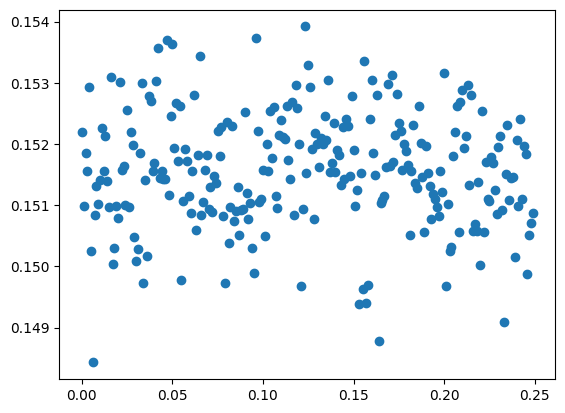

In [ ]:
params, pcoc  = curve_fit(power_law,ts[0],χsc)
plt.scatter(ts[0],χsc)